# Customer Churn Prediction
Production-ready ML notebook

## 1. Business Problem
Predict whether a customer is likely to stop purchasing using customer-level behavioural features.

## 2. Business Objectives
- Predict churn
- Identify drivers
- Recommend retention actions

## 3. ML Workflow
Business Understanding → Feature Engineering → Modeling → Evaluation → Interpretation

In [15]:

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (roc_auc_score,precision_score,recall_score,f1_score,
                             confusion_matrix,classification_report,
                             RocCurveDisplay,PrecisionRecallDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import shap
import joblib


## 4. Load Dataset

In [3]:

from pathlib import Path

DATA_PATH = Path("../data/processed/master_df.parquet")
master_df = pd.read_parquet(DATA_PATH)

master_df.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_name,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,720fd9e9-cdeb-4dec-a187-f71586eb085a,1e2e2881-a0eb-4cb0-829f-a566e810d05f,canceled,2025-12-27 07:07:20,2025-12-27 08:33:20,NaT,NaT,2026-01-04 08:33:20,d45cdff2-5195-41e2-a0e5-6fe597e378dd,James Ramos,...,1,paypal,1,2084.010010,None,NaN,None,None,NaT,NaT
1,720fd9e9-cdeb-4dec-a187-f71586eb085a,1e2e2881-a0eb-4cb0-829f-a566e810d05f,canceled,2025-12-27 07:07:20,2025-12-27 08:33:20,NaT,NaT,2026-01-04 08:33:20,d45cdff2-5195-41e2-a0e5-6fe597e378dd,James Ramos,...,1,paypal,1,2084.010010,None,NaN,None,None,NaT,NaT
2,720fd9e9-cdeb-4dec-a187-f71586eb085a,1e2e2881-a0eb-4cb0-829f-a566e810d05f,canceled,2025-12-27 07:07:20,2025-12-27 08:33:20,NaT,NaT,2026-01-04 08:33:20,d45cdff2-5195-41e2-a0e5-6fe597e378dd,James Ramos,...,1,paypal,1,2084.010010,None,NaN,None,None,NaT,NaT
3,c0142972-63fa-4af2-8070-f583ab769847,380b7418-308c-4bf7-b2bd-3ee446cb9ea6,delivered,2019-06-07 19:30:44,2019-06-08 05:08:44,2019-06-09 05:08:44,2019-06-14 05:08:44,2019-06-16 05:08:44,35cee471-325e-4ad2-8e4e-7b169dc6df81,Brian Jackson,...,1,credit_card,6,1406.069946,0ba49642-47bb-4817-9cc2-bb9ded7de7c5,5.0,Perfect,The quality is amazing. Delivery was quick.,2019-06-19 05:08:44,2019-06-19 07:08:44
4,c0142972-63fa-4af2-8070-f583ab769847,380b7418-308c-4bf7-b2bd-3ee446cb9ea6,delivered,2019-06-07 19:30:44,2019-06-08 05:08:44,2019-06-09 05:08:44,2019-06-14 05:08:44,2019-06-16 05:08:44,35cee471-325e-4ad2-8e4e-7b169dc6df81,Brian Jackson,...,1,credit_card,6,1406.069946,0ba49642-47bb-4817-9cc2-bb9ded7de7c5,5.0,Perfect,The quality is amazing. Delivery was quick.,2019-06-19 05:08:44,2019-06-19 07:08:44


## 5. Dataset Overview

In [4]:
master_df.shape
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2530433 entries, 0 to 2530432
Data columns (total 49 columns):
 #   Column                         Dtype         
---  ------                         -----         
 0   order_id                       object        
 1   customer_id                    object        
 2   order_status                   category      
 3   order_purchase_timestamp       datetime64[ns]
 4   order_approved_at              datetime64[ns]
 5   order_delivered_carrier_date   datetime64[ns]
 6   order_delivered_customer_date  datetime64[ns]
 7   order_estimated_delivery_date  datetime64[ns]
 8   customer_unique_id             object        
 9   customer_name                  object        
 10  customer_gender                category      
 11  customer_age                   int8          
 12  customer_zip_code_prefix       int32         
 13  customer_city                  object        
 14  customer_state                 category      
 15  customer_segmen

## 6. Data Quality Check

In [5]:
pd.DataFrame({
    "dtype": master_df.dtypes,
    "missing": master_df.isna().sum(),
    "missing_%": (master_df.isna().mean()*100).round(2)
}).sort_values("missing_%", ascending=False)

,dtype,missing,missing_%
order_delivered_customer_date,datetime64[ns],167729,6.63
order_delivered_carrier_date,datetime64[ns],167729,6.63
review_score,float32,167729,6.63
review_comment_title,object,167729,6.63
review_comment_message,object,167729,6.63
review_id,object,167729,6.63
review_creation_date,datetime64[ns],167729,6.63
review_answer_timestamp,datetime64[ns],167729,6.63
order_id,object,0,0.00
customer_name,object,0,0.00


## 7. Missing Values Handling

In [6]:
master_df["delivery_delay"] = (
    master_df["order_delivered_customer_date"] -
    master_df["order_estimated_delivery_date"]
).dt.days

master_df["delivery_time"] = (
    master_df["order_delivered_customer_date"] -
    master_df["order_purchase_timestamp"]
).dt.days

customer_features = (
    master_df.groupby("customer_unique_id")
    .agg(
        Avg_Delivery_Delay=("delivery_delay", "mean"),
        Avg_Delivery_Time=("delivery_time", "mean")
    )
)


customer_features["Avg_Delivery_Delay"] = (
    customer_features["Avg_Delivery_Delay"].fillna(0)
)

customer_features["Avg_Delivery_Time"] = (
    customer_features["Avg_Delivery_Time"].fillna(0)
)


customer_review = (
    master_df.groupby("customer_unique_id")
    .agg(
        Avg_Review_Score=("review_score", "mean")
    )
)

customer_review["Avg_Review_Score"] = (
    customer_review["Avg_Review_Score"]
    .fillna(customer_review["Avg_Review_Score"].mean())
)

customer_review["Avg_Review_Score"] = (
    customer_review["Avg_Review_Score"].fillna(0)
)

### Missing Value Handling

The missing values are limited to delivery and customer review information (approximately 6.63% of records). These missing values are business-related rather than data quality issues.

- Delivery dates are unavailable for cancelled, unavailable, or undelivered orders.
- Customer reviews are optional, so some orders have no review information.

Instead of imputing values in the original dataset, missing values are handled during customer-level feature engineering:

- Delivery-based features are calculated only for completed deliveries, and customers with no delivery history receive a value of 0.
- Average review scores are computed per customer, and customers without reviews are assigned the overall average review score.

This approach preserves the integrity of the original dataset while producing a complete feature matrix for machine learning.

## 8. Duplicate Analysis

In [7]:
print("Duplicate rows:", master_df.duplicated().sum())

Duplicate rows: 0


## 9. Churn Definition

### Business Definition

The original dataset does not contain a predefined churn label. Therefore, a customer-level churn target is created based on purchasing behavior.

A customer is considered **churned** if they have not made a purchase within the last **180 days** from the most recent purchase date in the dataset.

This rule is commonly used in transactional ecommerce datasets where customer inactivity is a proxy for churn.

**Churn Definition**

- Churn = 1 → Customer inactive for more than 180 days
- Churn = 0 → Customer purchased within the last 180 days

This binary target variable will be used for supervised machine learning.

## 10. Customer Feature Engineering

In [13]:
# ============================================================
# Customer Feature Engineering
# ============================================================

# Reference date
reference_date = master_df["order_purchase_timestamp"].max()

# ------------------------------------------------------------
# Create Delivery Features
# ------------------------------------------------------------

master_df["Delivery_Delay"] = (
    master_df["order_delivered_customer_date"] -
    master_df["order_estimated_delivery_date"]
).dt.days

master_df["Delivery_Time"] = (
    master_df["order_delivered_customer_date"] -
    master_df["order_purchase_timestamp"]
).dt.days

# ------------------------------------------------------------
# Customer-Level Feature Engineering
# ------------------------------------------------------------


reference_date=master_df["order_purchase_timestamp"].max()

customer_df=(
    master_df.groupby("customer_unique_id")
    .agg(
        Total_Orders=("order_id","nunique"),
        Total_Spend=("payment_value","sum"),
        Average_Order_Value=("payment_value","mean"),
        Last_Purchase=("order_purchase_timestamp","max"),
        Frequency=("order_id","nunique"),
        Monetary=("payment_value","sum"),
        Avg_Review_Score=("review_score","mean"),
        Avg_Delivery_Delay=(
            "order_delivered_customer_date",
            lambda x: (
                (x-master_df.loc[x.index,"order_estimated_delivery_date"])
                .dt.days.clip(lower=0).mean()
            )
        ),
        Avg_Discount=("discount_rate","mean"),
        Avg_Freight=("freight_value","mean"),
        Payment_Method=("payment_type",lambda x:x.mode().iloc[0] if not x.mode().empty else np.nan),
        Product_Diversity=("product_category_name","nunique")
    )
    .reset_index()
)

# ------------------------------------------------------------
# RFM Features
# ------------------------------------------------------------

customer_df["Recency"] = (reference_date - customer_df["Last_Purchase"]).dt.days

customer_df["Frequency"] = customer_df["Total_Orders"]

customer_df["Monetary"] = customer_df["Total_Spend"]

customer_df["Months_Since_Last_Purchase"] = (
    customer_df["Recency"] / 30
).round(1)

# ------------------------------------------------------------
# Handle Missing Values
# ------------------------------------------------------------

customer_df["Avg_Delivery_Delay"] = (
    customer_df["Avg_Delivery_Delay"].fillna(0)
)

customer_df["Avg_Review_Score"] = (
    customer_df["Avg_Review_Score"].fillna(
        customer_df["Avg_Review_Score"].mean()
    )
)

# ------------------------------------------------------------
# Create Churn Target
# ------------------------------------------------------------


customer_df["Churn"]=(customer_df["Recency"]>180).astype(int)

customer_df["Churn"].value_counts(normalize=True)

#avoid leakaage of recency into the model by creating a new feature for months 4
#since last purchase and dropping the last purchase date column
customer_df["Months_Since_Last_Purchase"]=customer_df["Recency"]/30
customer_df.drop(columns="Last_Purchase",inplace=True)
# ------------------------------------------------------------
# Final Dataset
# ------------------------------------------------------------

print(f"Customer Dataset Shape : {customer_df.shape}")

display(customer_df.head())

customer_df.info()

print("\nMissing Values:")
display(customer_df.isna().sum())

Customer Dataset Shape : (279199, 15)


,customer_unique_id,Total_Orders,Total_Spend,Average_Order_Value,Frequency,Monetary,Avg_Review_Score,Avg_Delivery_Delay,Avg_Discount,Avg_Freight,Payment_Method,Product_Diversity,Recency,Months_Since_Last_Purchase,Churn
0,00000ce0-2e08-4b89-ba86-0c8698b2d4fb,2,1293.010010,646.505005,2,1293.010010,5.000000,0.000000,0.000000,106.354996,bank_transfer,2,247,8.233333,1
1,00004453-ecfa-4c25-94f1-0004cc58286f,2,2119.609863,529.902466,2,2119.609863,5.000000,0.000000,0.055000,98.607498,boleto,4,599,19.966667,1
2,000062e5-a9a0-4056-a54d-5cf0b2473fda,1,10559.699219,3519.899658,1,10559.699219,4.000000,0.000000,0.000000,163.963333,paypal,2,58,1.933333,0
3,000076de-9d04-4ae8-af41-2f8caf66c899,5,35451.160156,2215.697510,5,35451.160156,3.500000,0.937500,0.013750,104.887497,credit_card,5,136,4.533333,0
4,00008df1-f9ce-487d-b5a6-68e6992e025a,7,23748.980469,1396.998901,7,23748.980469,3.823529,0.588235,0.015294,137.868240,credit_card,6,54,1.800000,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279199 entries, 0 to 279198
Data columns (total 15 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   customer_unique_id          279199 non-null  object  
 1   Total_Orders                279199 non-null  int64   
 2   Total_Spend                 279199 non-null  float32 
 3   Average_Order_Value         279199 non-null  float32 
 4   Frequency                   279199 non-null  int64   
 5   Monetary                    279199 non-null  float32 
 6   Avg_Review_Score            279199 non-null  float32 
 7   Avg_Delivery_Delay          279199 non-null  float64 
 8   Avg_Discount                279199 non-null  float32 
 9   Avg_Freight                 279199 non-null  float32 
 10  Payment_Method              279199 non-null  category
 11  Product_Diversity           279199 non-null  int64   
 12  Recency                     279199 non-null  int64   
 13 

customer_unique_id            0
Total_Orders                  0
Total_Spend                   0
Average_Order_Value           0
Frequency                     0
Monetary                      0
Avg_Review_Score              0
Avg_Delivery_Delay            0
Avg_Discount                  0
Avg_Freight                   0
Payment_Method                0
Product_Diversity             0
Recency                       0
Months_Since_Last_Purchase    0
Churn                         0
dtype: int64

## 11. Correlation Analysis

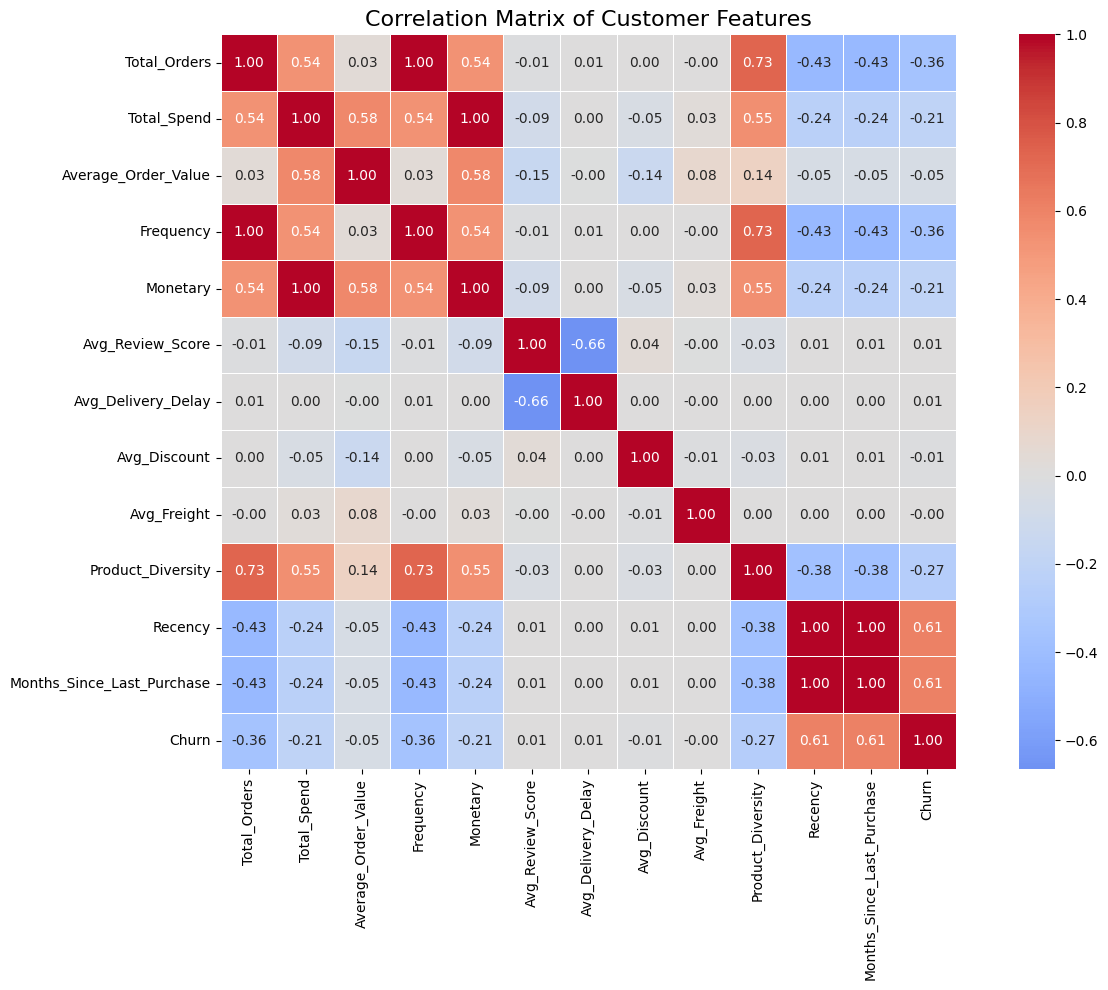

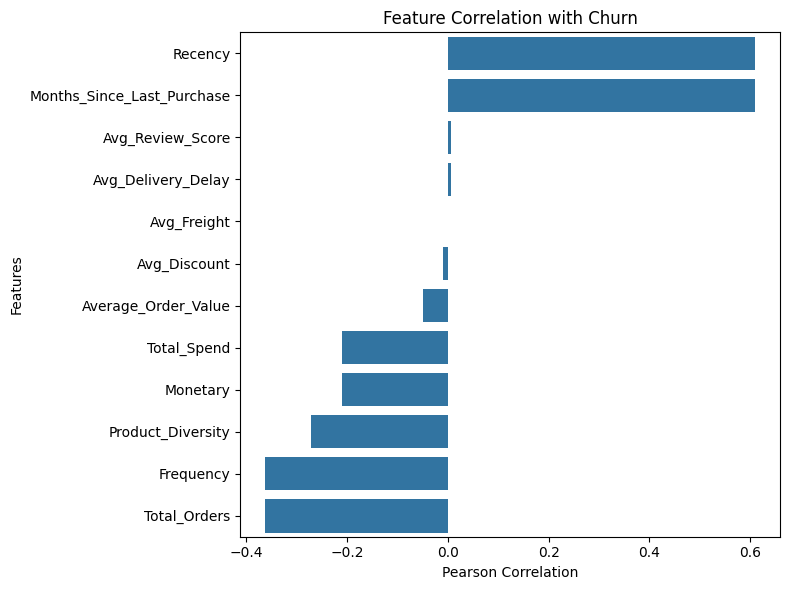

Correlation with Churn


,Correlation
Recency,0.610095
Months_Since_Last_Purchase,0.610095
Avg_Review_Score,0.006611
Avg_Delivery_Delay,0.005750
Avg_Freight,-0.000279
Avg_Discount,-0.008822
Average_Order_Value,-0.049742
Total_Spend,-0.209228
Monetary,-0.209228
Product_Diversity,-0.270459



Correlation Analysis Completed.


In [16]:
# ============================================================
# 11. Correlation Analysis
# ============================================================

# Select numerical features
numeric_df = customer_df.select_dtypes(include=["number"])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# ------------------------------------------------------------
# Correlation Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)

plt.title("Correlation Matrix of Customer Features", fontsize=16)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Correlation with Churn
# ------------------------------------------------------------

churn_corr = (
    corr_matrix["Churn"]
    .drop("Churn")
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,6))

sns.barplot(
    x=churn_corr.values,
    y=churn_corr.index
)

plt.title("Feature Correlation with Churn")
plt.xlabel("Pearson Correlation")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

print("=" * 60)
print("Correlation with Churn")
print("=" * 60)

display(churn_corr.to_frame("Correlation"))

print("\nCorrelation Analysis Completed.")

## 12. Class Imbalance Analysis

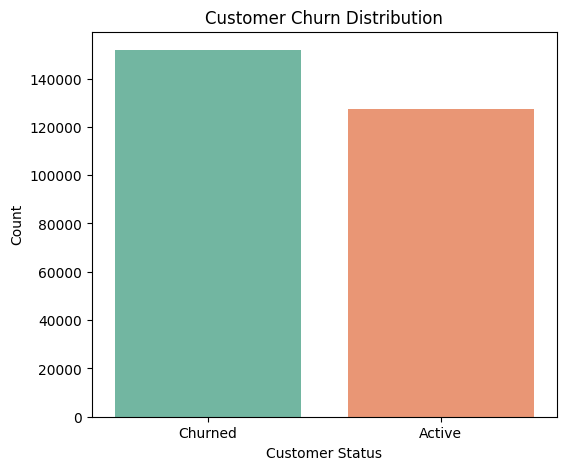

In [17]:
plt.figure(figsize=(6,5))

sns.countplot(
    x=customer_df["Churn"].map({0: "Active", 1: "Churned"}),
    palette="Set2"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Count")

plt.show()

## 13. Train/Test Split

In [27]:

# Recency defines the churn label, so it must not be used as a model feature.
leakage_cols = [
    "customer_unique_id",
    "Churn",
    "Recency",
    "Months_Since_Last_Purchase"
]

X = customer_df.drop(columns=leakage_cols)
y = customer_df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

print(type(X_train))
print(type(X_test))

Training Shape : (223359, 11)
Testing Shape  : (55840, 11)
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


## 14. Pipeline-based Preprocessing

In [29]:
# ==========================================================
# Identify Numerical & Categorical Columns
# ==========================================================

cat_cols = X_train.select_dtypes( include=["object", "category"]).columns.tolist()

num_cols = X_train.select_dtypes( exclude=["object", "category"]).columns.tolist()

print("Numerical Columns :", len(num_cols))
print("Categorical Columns :", len(cat_cols))

# ==========================================================
# Preprocessing Pipeline
# ==========================================================

numeric_transformer = Pipeline( steps=[("imputer", SimpleImputer(strategy="median")),
                                      ("scaler", StandardScaler())])

categorical_transformer = Pipeline( steps=[("imputer", SimpleImputer(strategy="most_frequent")),
                                           ("onehot", OneHotEncoder(handle_unknown="ignore"))] )

preprocessor = ColumnTransformer(transformers=[("num", numeric_transformer, num_cols),
                                               ("cat", categorical_transformer, cat_cols)] )

Numerical Columns : 10
Categorical Columns : 1


## 15. Logistic Regression

In [31]:
# Logistic Regression Pipeline

log_reg_pipeline = Pipeline( steps=[("preprocessor", preprocessor),
                                    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
                                    ])

log_reg_pipeline.fit(X_train, y_train)

# Predictions

y_pred = log_reg_pipeline.predict(X_test)
y_prob = log_reg_pipeline.predict_proba(X_test)[:, 1]

# 7. Evaluation

print("=" * 60)
print("Logistic Regression Results")
print("=" * 60)

print(f"ROC-AUC Score : {roc_auc_score(y_test, y_prob):.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Logistic Regression Results
ROC-AUC Score : 0.7157

Classification Report

              precision    recall  f1-score   support

           0       0.66      0.51      0.58     25480
           1       0.66      0.78      0.71     30360

    accuracy                           0.66     55840
   macro avg       0.66      0.65      0.65     55840
weighted avg       0.66      0.66      0.65     55840



## 16. Random Forest

In [ ]:
# Random Forest Pipeline
rf_pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", RandomForestClassifier(random_state=42))])
rf_pipeline.fit(X_train, y_train)

# Predictions
rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

# Evaluation
print("=" * 60)
print("Random Forest Results")
print("=" * 60)
print(f"ROC-AUC Score : {roc_auc_score(y_test, rf_prob):.4f}")
print("\nClassification Report\n")
print(classification_report(y_test, rf_pred))


## 17. XGBoost

In [ ]:
# XGBoost Pipeline
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(eval_metric="logloss", random_state=42, n_estimators=200, learning_rate=0.05, max_depth=4))
])
xgb_pipeline.fit(X_train, y_train)

# Predictions
xgb_pred = xgb_pipeline.predict(X_test)
xgb_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

# Evaluation
print("=" * 60)
print("XGBoost Results")
print("=" * 60)
print(f"ROC-AUC Score : {roc_auc_score(y_test, xgb_prob):.4f}")
print("\nClassification Report\n")
print(classification_report(y_test, xgb_pred))


## 18. LightGBM

In [ ]:
# LightGBM Pipeline
lgbm_pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", LGBMClassifier(random_state=42, verbosity=-1))])
lgbm_pipeline.fit(X_train, y_train)

# Predictions
lgbm_pred = lgbm_pipeline.predict(X_test)
lgbm_prob = lgbm_pipeline.predict_proba(X_test)[:, 1]

# Evaluation
print("=" * 60)
print("LightGBM Results")
print("=" * 60)
print(f"ROC-AUC Score : {roc_auc_score(y_test, lgbm_prob):.4f}")
print("\nClassification Report\n")
print(classification_report(y_test, lgbm_pred))


## 19. Cross Validation

In [ ]:
# Cross validation for all models
models = {"Logistic Regression": log_reg_pipeline, "Random Forest": rf_pipeline, "XGBoost": xgb_pipeline, "LightGBM": lgbm_pipeline}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    cv_results.append({"Model": name, "CV Accuracy Mean": scores.mean(), "CV Accuracy Std": scores.std()})

cv_results = pd.DataFrame(cv_results).sort_values("CV Accuracy Mean", ascending=False)
best_model_name = cv_results.iloc[0]["Model"]
display(cv_results)
print(f"Best model by CV accuracy: {best_model_name}")


## 20. Hyperparameter Tuning

In [ ]:
# Tune the model with the highest cross-validation accuracy
param_distributions = {
    "Logistic Regression": {"classifier__C": [0.01, 0.1, 1, 10]},
    "Random Forest": {"classifier__n_estimators": [100, 200, 300], "classifier__max_depth": [None, 5, 10], "classifier__min_samples_split": [2, 5]},
    "XGBoost": {"classifier__n_estimators": [100, 200, 300], "classifier__max_depth": [3, 4, 5], "classifier__learning_rate": [0.01, 0.05, 0.1]},
    "LightGBM": {"classifier__n_estimators": [100, 200, 300], "classifier__num_leaves": [15, 31, 63], "classifier__learning_rate": [0.01, 0.05, 0.1]}
}
search = RandomizedSearchCV(estimator=models[best_model_name], param_distributions=param_distributions[best_model_name], n_iter=5, scoring="accuracy", cv=3, random_state=42, n_jobs=-1)
search.fit(X_train, y_train)
best_pipeline = search.best_estimator_
best_pred = best_pipeline.predict(X_test)
best_prob = best_pipeline.predict_proba(X_test)[:, 1]
print(f"Tuned model: {best_model_name}")
print("Best parameters:", search.best_params_)
print(f"Test Accuracy: {(best_pred == y_test).mean():.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, best_prob):.4f}")


## 21. Model Comparison Table

In [ ]:
# Model comparison on the test set
model_predictions = {
    "Logistic Regression": (y_pred, y_prob),
    "Random Forest": (rf_pred, rf_prob),
    "XGBoost": (xgb_pred, xgb_prob),
    "LightGBM": (lgbm_pred, lgbm_prob),
    f"Tuned {best_model_name}": (best_pred, best_prob)
}
comparison = pd.DataFrame([{"Model": name, "Accuracy": (predictions == y_test).mean(), "ROC-AUC": roc_auc_score(y_test, probabilities)} for name, (predictions, probabilities) in model_predictions.items()]).sort_values("Accuracy", ascending=False)
display(comparison)


## 22. ROC Curves

In [ ]:
# ROC curves
plt.figure(figsize=(8, 6))
for name, (_, probabilities) in model_predictions.items():
    RocCurveDisplay.from_predictions(y_test, probabilities, name=name)
plt.title("ROC Curves")
plt.show()


## 23. Precision-Recall Curves

In [ ]:
# Precision-recall curves
plt.figure(figsize=(8, 6))
for name, (_, probabilities) in model_predictions.items():
    PrecisionRecallDisplay.from_predictions(y_test, probabilities, name=name)
plt.title("Precision-Recall Curves")
plt.show()


## 24. Confusion Matrices

In [ ]:
# Confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()
for ax, (name, (predictions, _)) in zip(axes, model_predictions.items()):
    sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
for ax in axes[len(model_predictions):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()


## 25. Classification Reports

In [ ]:
# Classification reports
for name, (predictions, _) in model_predictions.items():
    print("=" * 60)
    print(name)
    print("=" * 60)
    print(classification_report(y_test, predictions))


## 26. Feature Importance

In [ ]:
# Feature importance from the tuned best model
best_preprocessor = best_pipeline.named_steps["preprocessor"]
best_classifier = best_pipeline.named_steps["classifier"]
feature_names = best_preprocessor.get_feature_names_out()

if hasattr(best_classifier, "feature_importances_"):
    importance_values = best_classifier.feature_importances_
else:
    importance_values = np.abs(best_classifier.coef_[0])

feature_importance = pd.DataFrame({"Feature": feature_names, "Importance": importance_values}).sort_values("Importance", ascending=False).head(20)
plt.figure(figsize=(12, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance)
plt.title(f"Top 20 Feature Importances - Tuned {best_model_name}")
plt.show()
display(feature_importance)


## 27. SHAP Summary

In [ ]:
# SHAP feature importance for the tuned best model
shap_data = X_test.sample(min(500, len(X_test)), random_state=42)
shap_features = best_preprocessor.transform(shap_data)
if hasattr(shap_features, "toarray"):
    shap_features = shap_features.toarray()

if hasattr(best_classifier, "feature_importances_"):
    explainer = shap.TreeExplainer(best_classifier)
else:
    explainer = shap.LinearExplainer(best_classifier, shap_features)

shap_values = explainer.shap_values(shap_features)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
if np.ndim(shap_values) == 3:
    shap_values = shap_values[:, :, 1]

shap_importance = pd.DataFrame({"Feature": feature_names, "Importance": np.abs(shap_values).mean(axis=0)}).sort_values("Importance", ascending=False).head(20)
plt.figure(figsize=(12, 6))
sns.barplot(x="Importance", y="Feature", data=shap_importance)
plt.title(f"Top 20 SHAP Feature Importances - Tuned {best_model_name}")
plt.show()
display(shap_importance)


## 28. Model Export (joblib)

In [ ]:
# Export the tuned best pipeline
joblib.dump(best_pipeline, "customer_churn_model.joblib")
print(f"Tuned {best_model_name} model exported.")


## 29. Business Insights

In [ ]:
# Business insights from the most important features
print(f"The tuned {best_model_name} model is the selected churn model.")
print("Top churn drivers:")
display(feature_importance[["Feature", "Importance"]].head(5))


## 30. Retention Strategies

In [ ]:
# Retention strategies
print("Retention strategies:")
print("1. Target customers with high-risk feature values using personalised offers.")
print("2. Improve delivery and service issues highlighted by the important features.")
print("3. Engage customers before they become inactive with timely reminders.")


## 31. Executive Summary

In [ ]:
# Executive summary
print("Customer churn prediction workflow completed.")
print(f"Selected model: Tuned {best_model_name}")
print(f"Test accuracy: {(best_pred == y_test).mean():.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, best_prob):.4f}")
print("Use the feature importance and SHAP plots to guide retention actions.")
